# ARIMA-based Models

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.models.sarima import *

In [2]:
inf_data = pd.read_csv('..//data//processed//combined_macro_data.csv').set_index(['Date'])
inf_data.index = pd.to_datetime(inf_data.index)
inf_rate = inf_data['InflationRate'].dropna()

In [3]:
n_splits = 5
months_ahead = 6
test_size = months_ahead

inf_train = inf_rate[:-test_size]
inf_test = inf_rate[-test_size:]

## I. SARIMA

In [4]:
sarimax_test(ts_data=inf_train, test_size = test_size, n_splits=n_splits)

Folds: 5
Test Size: 6


,RMSE,MAE,MSE,MAPE,STD
Fold,,,,,
1,0.744950,0.641340,0.554951,12.479072,0.617241
2,0.204657,0.188314,0.041885,5.513068,0.395544
3,0.667617,0.561599,0.445712,23.434181,0.859741
4,0.671411,0.551651,0.450793,35.338132,0.644405
5,0.196591,0.159720,0.038648,10.508183,0.256492


In [5]:
nexog_test_model, nexog_test_forecast, nexog_test_conf = sarimax_forecast(ts_data=inf_train.dropna(), n_forecast=test_size)
print(nexog_test_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  815
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 12)   Log Likelihood               -1199.223
Date:                              Wed, 15 Jul 2026   AIC                           2408.447
Time:                                      16:42:27   BIC                           2431.957
Sample:                                  01-01-1958   HQIC                          2417.471
                                       - 11-01-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8826      0.022     41.020      0.000       0.840       0.925
ma.L1         -0.53

In [6]:
eval_metrics(inf_test, nexog_test_forecast)

{'RMSE': 2.929000190983746,
 'MAE': 2.332112326159217,
 'MSE': 8.579042118782821,
 'MAPE': 50.13197375543731,
 'STD': 2.2082739170581256}

In [7]:
nexog_model, nexog_forecast, nexog_conf = sarimax_forecast(ts_data=inf_rate, n_forecast=months_ahead)
print(nexog_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  821
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 12)   Log Likelihood               -1209.392
Date:                              Wed, 15 Jul 2026   AIC                           2428.784
Time:                                      16:42:53   BIC                           2452.330
Sample:                                  01-01-1958   HQIC                          2437.819
                                       - 05-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8826      0.022     40.765      0.000       0.840       0.925
ma.L1         -0.53

In [8]:
nexog_forecast.name = 'NExog Full Forecast'
low = pd.Series(nexog_conf[:,0], name = 'Low', index = nexog_forecast.index)
high = pd.Series(nexog_conf[:,1], name = 'High', index = nexog_forecast.index)
full_nexog_forecast = pd.concat([nexog_forecast, low, high], axis = 1)
full_nexog_forecast.to_csv('..//outputs//forecasts//full_nexog_forecast.csv')

full_nexog_forecast

,NExog Full Forecast,Low,High
2026-06-01,7.036636,4.983075,9.090198
2026-07-01,7.390334,3.948259,10.832410
2026-08-01,7.378207,2.719343,12.037071
2026-09-01,7.795006,1.984366,13.605646
2026-10-01,8.106122,1.181588,15.030655
2026-11-01,8.447115,0.437395,16.456836


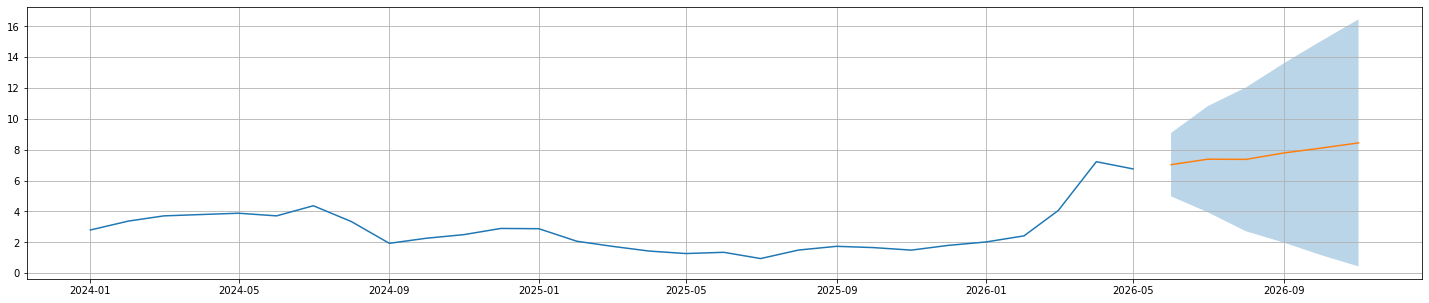

In [9]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.plot(full_nexog_forecast['NExog Full Forecast'])
plt.fill_between(full_nexog_forecast.index, full_nexog_forecast['Low'], full_nexog_forecast['High'], alpha = 0.3)
plt.grid(True)
plt.show()

## II. SARIMA (Reduced Data)

In [10]:
full_data = inf_data.dropna()
targ_col = 'InflationRate'

reduced_inf = full_data[targ_col]
reduced_inf_train = reduced_inf[:-test_size]
reduced_inf_test = reduced_inf[-test_size:]

In [11]:
sarimax_test(ts_data = reduced_inf_train, n_splits = n_splits, test_size = test_size)

Folds: 5
Test Size: 6


,RMSE,MAE,MSE,MAPE,STD
Fold,,,,,
1,0.669149,0.561170,0.447760,10.785953,0.617241
2,0.218721,0.156799,0.047839,4.546014,0.395544
3,0.701349,0.588565,0.491891,24.571356,0.859741
4,0.887487,0.711912,0.787633,46.766268,0.644405
5,0.248337,0.223722,0.061671,16.677535,0.256492


In [12]:
nexog_red_test_model, nexog_red_test_forecast, nexog_red_test_conf = sarimax_forecast(ts_data=reduced_inf_train, n_forecast=months_ahead)
print(nexog_red_test_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  251
Model:             SARIMAX(0, 1, 3)x(0, 0, [1], 12)   Log Likelihood                 -81.074
Date:                              Wed, 15 Jul 2026   AIC                            172.148
Time:                                      16:43:54   BIC                            189.755
Sample:                                  01-01-2005   HQIC                           179.234
                                       - 11-01-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4998      0.057      8.820      0.000       0.389       0.611
ma.L2          0.24

In [13]:
eval_metrics(reduced_inf_test, nexog_red_test_forecast)

{'RMSE': 2.8169154236145224,
 'MAE': 2.2652259649367705,
 'MSE': 7.935012503797385,
 'MAPE': 49.555272650720525,
 'STD': 2.2082739170581256}

In [14]:
nexog_red_model, nexog_red_forecast, nexog_red_conf = sarimax_forecast(ts_data = reduced_inf, n_forecast = months_ahead)
print(nexog_red_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  257
Model:             SARIMAX(0, 1, 1)x(2, 0, [], 12)   Log Likelihood                -139.621
Date:                             Wed, 15 Jul 2026   AIC                            287.243
Time:                                     16:44:02   BIC                            301.424
Sample:                                 01-01-2005   HQIC                           292.946
                                      - 05-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4899      0.038     13.045      0.000       0.416       0.564
ar.S.L12      -0.6005      

In [15]:
nexog_red_forecast.name = 'NExog Reduced Forecast'
low = pd.Series(nexog_red_conf[:,0], name = 'Low', index = nexog_red_forecast.index)
high = pd.Series(nexog_red_conf[:,1], name = 'High', index = nexog_red_forecast.index)
red_nexog_forecast = pd.concat([nexog_red_forecast, low, high], axis = 1)
red_nexog_forecast.to_csv('..//outputs//forecasts//red_nexog_forecast.csv')

red_nexog_forecast

,NExog Reduced Forecast,Low,High
2026-06-01,5.949502,5.139923,6.759082
2026-07-01,5.994330,4.541635,7.447025
2026-08-01,5.972430,4.084249,7.860612
2026-09-01,6.253181,4.012616,8.493747
2026-10-01,6.203763,3.659153,8.748372
2026-11-01,6.230273,3.414257,9.046288


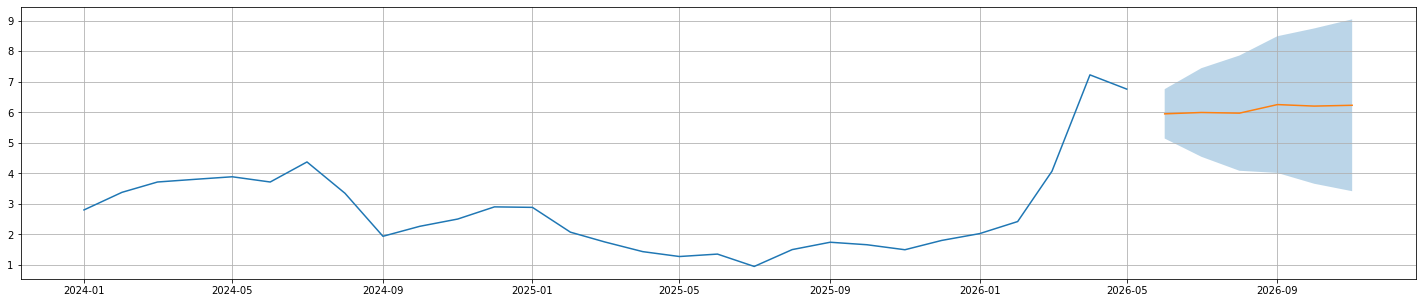

In [16]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.plot(red_nexog_forecast['NExog Reduced Forecast'])
plt.fill_between(red_nexog_forecast.index, red_nexog_forecast['Low'], red_nexog_forecast['High'], alpha = 0.3)
plt.grid(True)
plt.show()

## III. SARIMAX

In [17]:
reduced_inf_train = full_data[:-test_size]
reduced_inf_test = full_data[-test_size:]

In [18]:
sarimax_test(ts_data = reduced_inf_train, n_splits = n_splits, test_size = test_size, target_col = targ_col)

Folds: 5
Test Size: 6


,RMSE,MAE,MSE,MAPE,STD
Fold,,,,,
1,0.595872,0.484644,0.355063,9.223387,0.617241
2,0.186503,0.170153,0.034783,4.944261,0.395544
3,0.827917,0.710905,0.685447,29.424315,0.859741
4,0.988278,0.794168,0.976693,52.254196,0.644405
5,0.426454,0.364039,0.181863,25.520366,0.256492


In [19]:
exog_red_test_model, exog_red_test_forecast, exog_red_test_conf = sarimax_forecast(ts_data=reduced_inf_train, n_forecast=months_ahead, target_col = targ_col)
print(exog_red_test_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  251
Model:             SARIMAX(0, 1, 3)x(0, 0, [1], 12)   Log Likelihood                 -80.389
Date:                              Wed, 15 Jul 2026   AIC                            176.779
Time:                                      16:48:18   BIC                            204.951
Sample:                                  01-01-2005   HQIC                           188.117
                                       - 11-01-2025                                         
Covariance Type:                                opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
USD_PHP              0.0072      0.024      0.303      0.762      -0.039       0.054
U

In [20]:
eval_metrics(reduced_inf_test[targ_col], exog_red_test_forecast)

{'RMSE': 2.852985862362201,
 'MAE': 2.2952020949765406,
 'MSE': 8.139528330838592,
 'MAPE': 50.29590873573962,
 'STD': 2.2082739170581256}

In [21]:
exog_red_model, exog_red_forecast, exog_red_conf = sarimax_forecast(ts_data = full_data, n_forecast = months_ahead, target_col = targ_col)
print(exog_red_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  257
Model:             SARIMAX(0, 1, 1)x(2, 0, [], 12)   Log Likelihood                -139.128
Date:                             Wed, 15 Jul 2026   AIC                            292.256
Time:                                     16:48:48   BIC                            317.072
Sample:                                 01-01-2005   HQIC                           302.237
                                      - 05-01-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
USD_PHP              0.0281      0.040      0.705      0.481      -0.050       0.106
Unemploym

In [22]:
exog_red_forecast.name = 'Exog Reduced Forecast'
low = pd.Series(exog_red_conf[:,0], name = 'Low', index = exog_red_forecast.index)
high = pd.Series(exog_red_conf[:,1], name = 'High', index = exog_red_forecast.index)
red_exog_forecast = pd.concat([exog_red_forecast, low, high], axis = 1)
red_exog_forecast.to_csv('..//outputs//forecasts//red_exog_forecast.csv')

red_exog_forecast

,Exog Reduced Forecast,Low,High
2026-06-01,5.995039,5.186851,6.803226
2026-07-01,6.042879,4.592748,7.493010
2026-08-01,6.030859,4.146026,7.915691
2026-09-01,6.305279,4.068695,8.541862
2026-10-01,6.289556,3.749474,8.829638
2026-11-01,6.348040,3.537039,9.159042


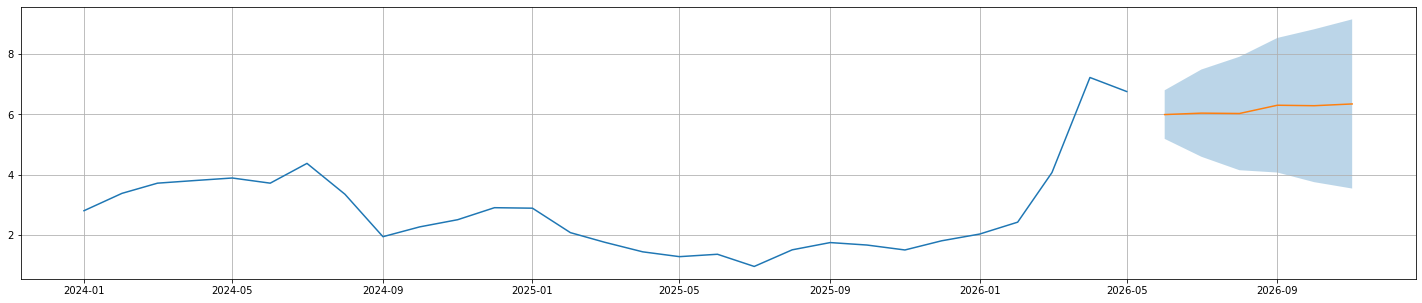

In [23]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.plot(red_exog_forecast['Exog Reduced Forecast'])
plt.fill_between(red_exog_forecast.index, red_exog_forecast['Low'], red_exog_forecast['High'], alpha = 0.3)
plt.grid(True)
plt.show()